<a href="https://colab.research.google.com/github/Mueez-lab/CustomerChurn_Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Advanced visualizations (like heatmaps, boxplots), built on top of matplotlib.
from sklearn.preprocessing import LabelEncoder # Converts categorical text labels (e.g., "Male", "Female") into numeric form (0, 1)
from imblearn.over_sampling import SMOTE #Stands for Synthetic Minority Over-sampling Technique.f you have fewer "churned" customers than "non-churned", SMOTE creates synthetic examples of the minority class to balance the datase
from sklearn.model_selection import train_test_split, cross_val_score # Cross-validation is a technique to test how well your model generalizes (performs on unseen data) by splitting your data into multiple parts (called “folds”).
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # A confusion matrix is a table that shows the performance of a classification model by comparing actual and predicted values.
import pickle #Let’s say you’ve trained a machine learning model (which takes time and resources). You can save it to a .pkl file and load it later without retraining.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [5]:
df = pd.read_csv('dataset.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Cleaning Data**

In [ ]:
pd.set_option('display.max_columns',None) # It sets a display option so that all columns of a DataFrame will be shown when printed — no matter how many columns there are.
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
#Customer_id is not important so we are droping it
df = df.drop(['customerID'],axis=1)

# drop if duplicate data
df.drop_duplicates()

numerical_features = ["tenure","MonthlyCharges","TotalCharges"]

In [7]:
#getting unique value from each column
for col in df.columns:
    if col not in numerical_features:
        print(col,df[col].unique())
        print("-"*100)
#to see number of missing values
#there were objects in .info() so it can't correctly tell if there is a null value or not
#Replace empty strings and spaces with NaN so that it can be detected
df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
#so after ruuning the the places with "" or " " are replaced by <nan>
print(df.isnull().sum())

gender ['Female' 'Male']
----------------------------------------------------------------------------------------------------
SeniorCitizen [0 1]
----------------------------------------------------------------------------------------------------
Partner ['Yes' 'No']
----------------------------------------------------------------------------------------------------
Dependents ['No' 'Yes']
----------------------------------------------------------------------------------------------------
PhoneService ['No' 'Yes']
----------------------------------------------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
----------------------------------------------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
----------------------------------------------------------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------

In [8]:
# Convertig object data into float

# replacing <nan> with 0.0
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)
df["TotalCharges"] = df["TotalCharges"].astype(float)


In [9]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


**Numerical Data Analysis**

In [10]:
# Checking the disyriution of target columns
print(df["Churn"].value_counts())

print(df.describe())

Churn
No     5174
Yes    1869
Name: count, dtype: int64
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


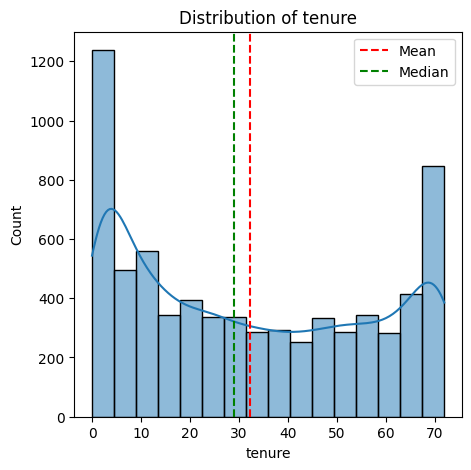

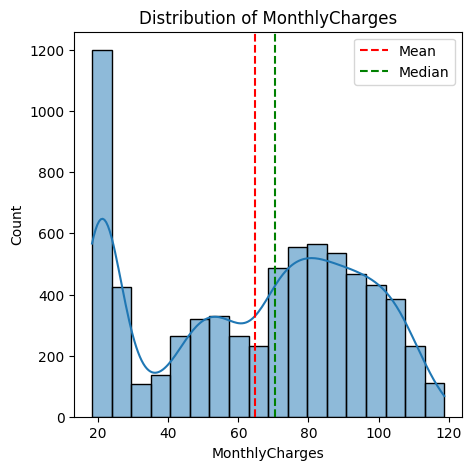

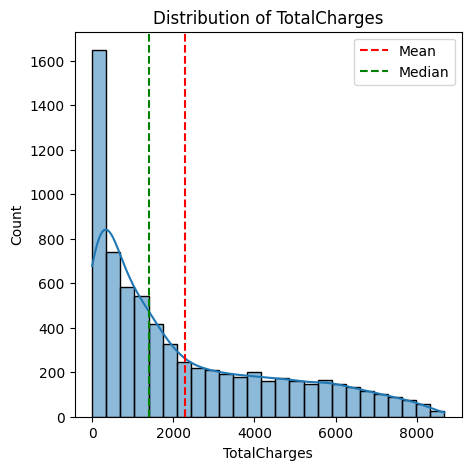

In [11]:
def plot_histogram(df,column_name):
    plt.figure(figsize=(5,5))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    # Calculate means and median values for the column
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="--", label="Median")

    plt.legend()
    plt.show()

plot_histogram(df,"tenure")
plot_histogram(df,"MonthlyCharges")
plot_histogram(df,"TotalCharges") # right skewed as u can see in graph so we will balance it

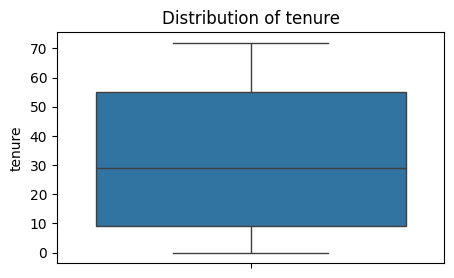

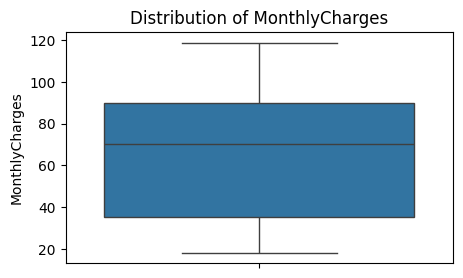

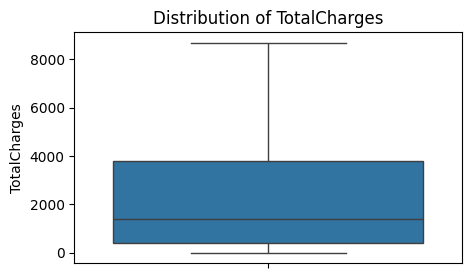

In [ ]:
def plot_boxplot(df,column_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Distribution of {column_name}")
    plt.ylabel(column_name)
    plt.show()

plot_boxplot(df,"tenure")
plot_boxplot(df,"MonthlyCharges")
plot_boxplot(df,"TotalCharges")


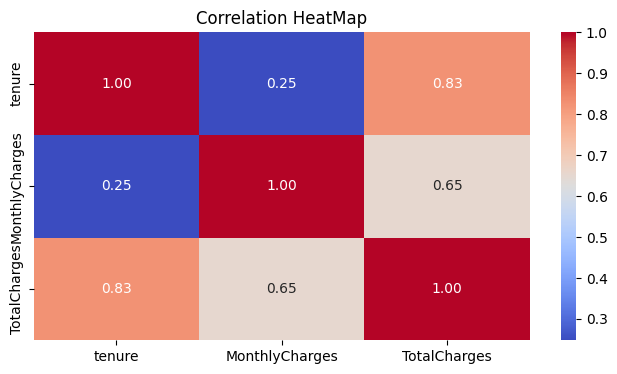

In [12]:
# correlation heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation HeatMap")
plt.show()

**Categorical Data Analysis**

In [13]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

CountPlot for categorical columns

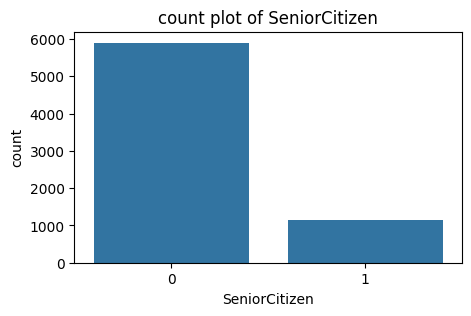

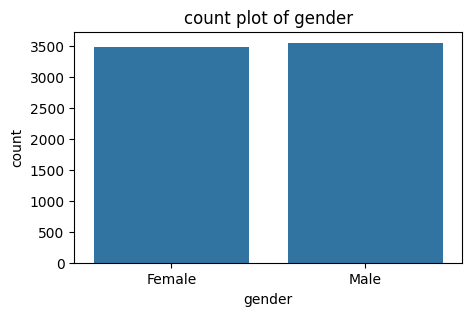

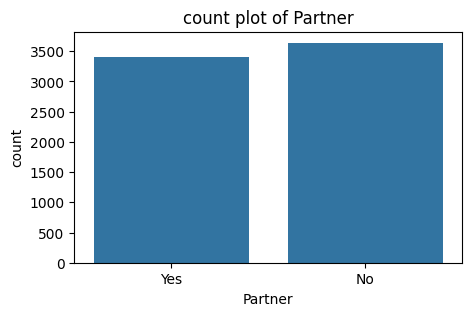

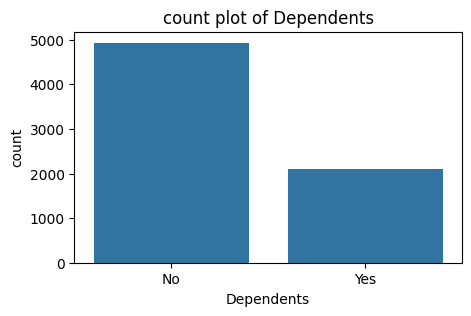

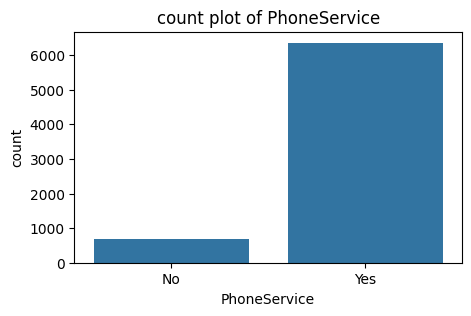

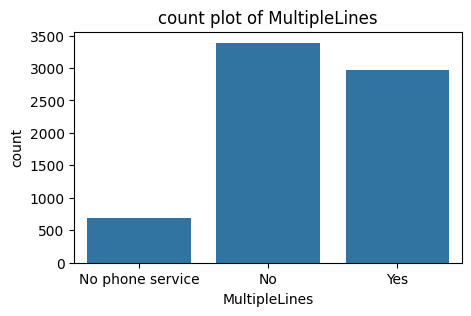

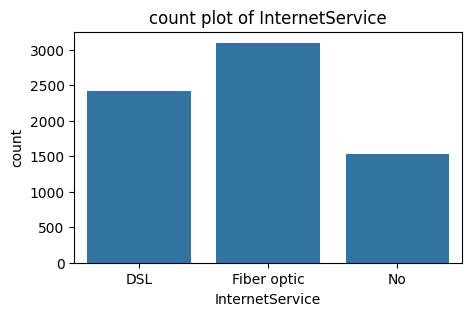

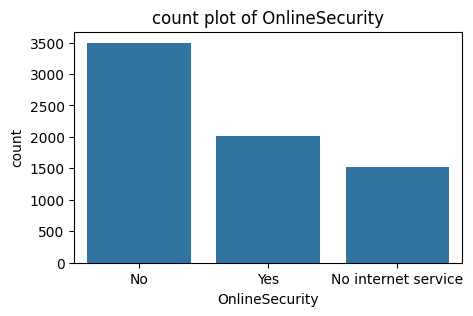

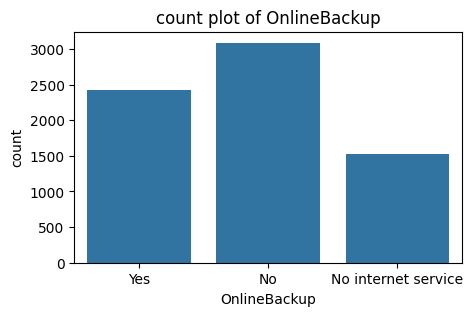

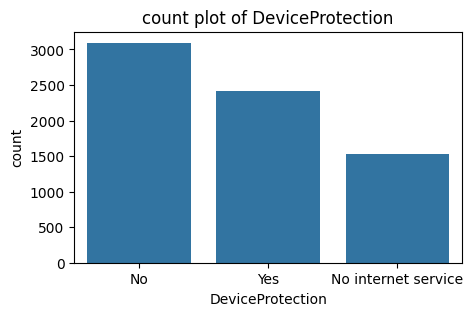

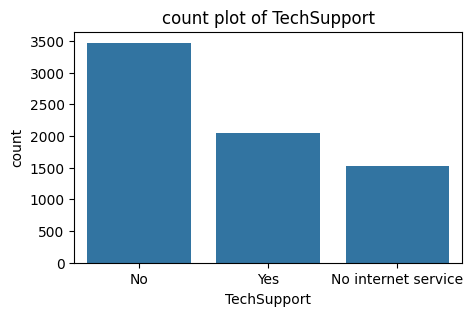

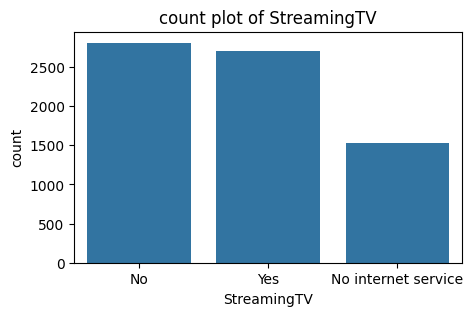

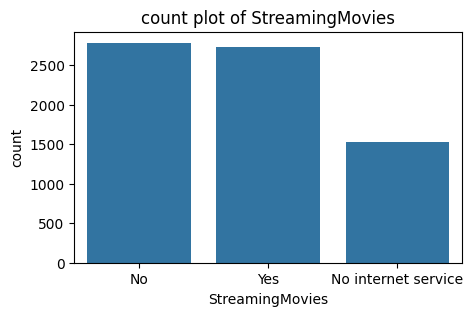

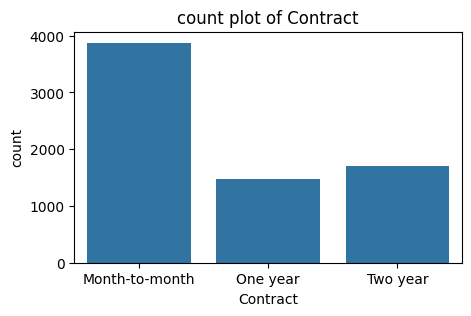

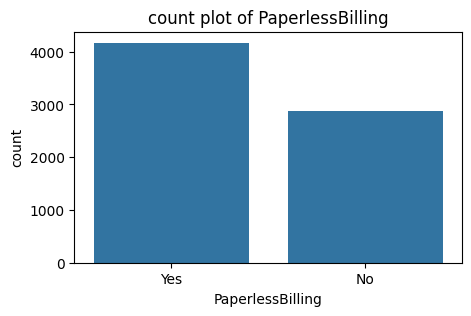

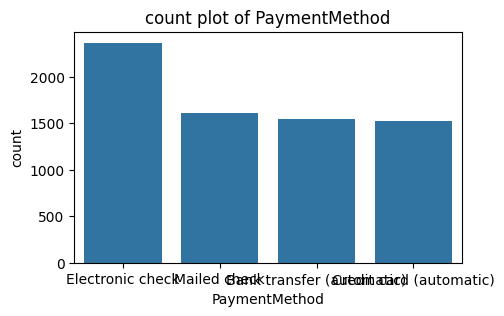

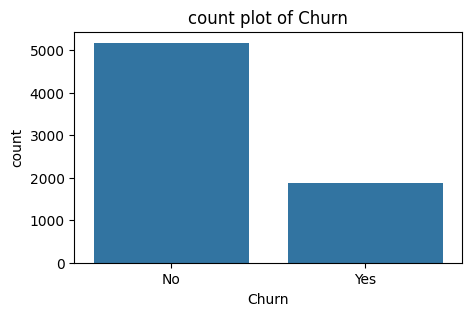

In [14]:
objects_col = df.select_dtypes(include=['object']).columns.tolist() # selects categorical data (objs)
objects_col = ["SeniorCitizen"] + objects_col # added seniorCitizen in it
for col in objects_col:
  plt.figure(figsize=(5,3))
  sns.countplot(x=df[col])
  plt.title(f"count plot of {col}")
  plt.show()

If my feature columns are unbalance then it is not going to effect my model But if my targent column is unbalanced then it going to put a huge effect on my model

**Data Preprocessing**

In [15]:
df.head(3)
#Converting categorical data into numerical form

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Lable encoding of target column

In [16]:
df["Churn"] = df["Churn"].astype(str).str.lower().replace({"yes": 1, "no": 0})
df["Churn"] = df["Churn"].to_numpy().astype(int)
df.head(3)



<ipython-input-16-df0f623601d5>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].astype(str).str.lower().replace({"yes": 1, "no": 0})


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [17]:
object_columns = df.select_dtypes(include=['object']).columns.tolist()
object_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [18]:
# Initilize the dictionary to save the encoder
encoders = {}

# Apply label encoding and store the encoders
for col in object_columns:
        Label_encoder = LabelEncoder()
        df[col] = Label_encoder.fit_transform(df[col])
        encoders[col] = Label_encoder
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
#Preserve the exact mapping used during training.
#pickle is used to serialize (save) the encoders dictionary to a file named encoders.pkl.
# This allows you to reuse the same encoders later (for example, when transforming test data). we can also decode it later on

In [19]:
encoders # different columns used different lableEncoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

**Train and Test data Split**

In [49]:
x= df.drop(['Churn'],axis=1)
y= df['Churn']

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42) #. If you don’t set random_state, it will: Shuffle the data differently every time you run it.

In [51]:
Y_train.value_counts()

,count
Churn,
0,4138
1,1496


Unbalanced so will use SMOTE technique (Synthetic Minority OverSampling Technique)

In [23]:
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [24]:
Y_train_smote.value_counts()

,count
Churn,
0,4138
1,4138


**Models**

In [52]:
models = {
    "DecisionTree" : DecisionTreeClassifier(random_state=42),
    "RandomForest" : RandomForestClassifier(random_state=42),
    "XGBoost" : XGBRFClassifier(random_state=42)
}

In [53]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for each model
param_grids = {
    "DecisionTree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    },
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2]
    }
}

# Store best models and scores
best_models = {}
cv_score = {}

# Run GridSearchCV for each model
for model_name, model in models.items():
    print(f"Hyperparameter tuning for {model_name}...")

    grid = GridSearchCV(estimator=model,
                        param_grid=param_grids[model_name],
                        cv=5,
                        scoring='accuracy',
                        n_jobs=-1)

    grid.fit(X_train_smote, Y_train_smote)

    best_models[model_name] = grid.best_estimator_
    cv_score[model_name] = grid.best_score_

    print(f"✅ Best Parameters for {model_name}: {grid.best_params_}")
    print(f"📈 Best CV Accuracy: {grid.best_score_:.4f}\n")


Hyperparameter tuning for DecisionTree...
✅ Best Parameters for DecisionTree: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}
📈 Best CV Accuracy: 0.8069

Hyperparameter tuning for RandomForest...
✅ Best Parameters for RandomForest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
📈 Best CV Accuracy: 0.8423

Hyperparameter tuning for XGBoost...
✅ Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
📈 Best CV Accuracy: 0.8133



So we are going to work with random forest because it has highest accuracy

In [54]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, Y_train_smote)

RandomForestClassifier(random_state=42)

In [55]:
# Evaluate on test data
# Accuracy Score is unreliable because test data is umbalanced
y_test_pred = rfc.predict(X_test)
accuracy = accuracy_score(Y_test, y_test_pred)
print(f"Test Accuracy\n {accuracy}")
conf_matrix = confusion_matrix(Y_test, y_test_pred)
print(f"Confusion Matrix\n {conf_matrix}")
classification_rep = classification_report(Y_test, y_test_pred)
print(f"Classification Report\n {classification_rep}")

Test Accuracy
 0.7785663591199432
Confusion Matrix
 [[878 158]
 [154 219]]
Classification Report
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



**Save the Trained Model as a Pickel File**

In [56]:
model_data = {
    'model': rfc,
    'features': x.columns.tolist(),
    'target': 'Churn',
    'encoders': encoders
}
with open('Customer_Churn_model.pkl', 'wb') as f: # w = write mode , b = binary mode
    pickle.dump(rfc, f)

Load the saved model and build a prediction

In [57]:
with open('Customer_Churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
    loaded_features = model_data['features']
    loaded_target = model_data['target']
    loaded_encoders = model_data['encoders']

In [58]:
print(loaded_model)
print(loaded_features)
print(loaded_target)
print(loaded_encoders)

RandomForestClassifier(random_state=42)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Churn
{'gender': LabelEncoder(), 'Partner': LabelEncoder(), 'Dependents': LabelEncoder(), 'PhoneService': LabelEncoder(), 'MultipleLines': LabelEncoder(), 'InternetService': LabelEncoder(), 'OnlineSecurity': LabelEncoder(), 'OnlineBackup': LabelEncoder(), 'DeviceProtection': LabelEncoder(), 'TechSupport': LabelEncoder(), 'StreamingTV': LabelEncoder(), 'StreamingMovies': LabelEncoder(), 'Contract': LabelEncoder(), 'PaperlessBilling': LabelEncoder(), 'PaymentMethod': LabelEncoder()}


In [59]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}
input_data_df = pd.DataFrame([input_data])
with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
# encode categorical features using the saved encoders
for columns , encoder in encoders.items():
  input_data_df[columns] = encoder.transform(input_data_df[columns])
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)
print(f"Prediction : {'Churn'  if prediction[0] == 1 else 'No Churn'}")
print(f"Prediction Probability : {pred_prob}")

Prediction : No Churn
Prediction Probability : [[0.78 0.22]]
